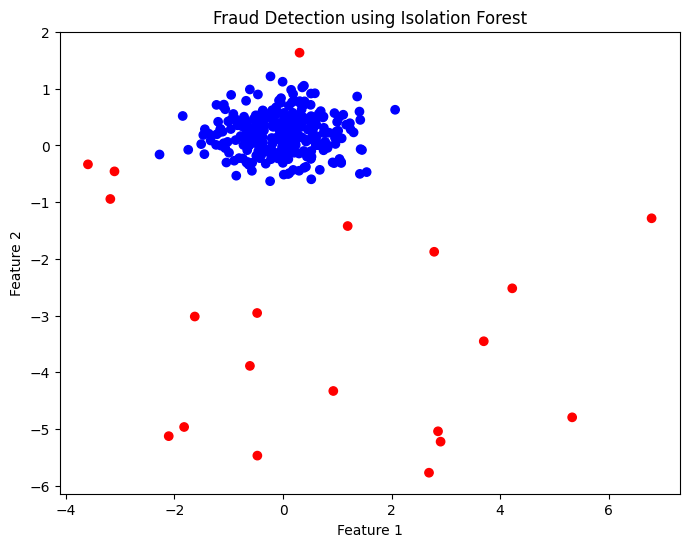

Fraudulent Transactions Detected: 20


In [2]:
# Fraud Detection using Isolation Forest

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

# Create Synthetic Dataset
X, _ = make_blobs(
    n_samples=300,
    centers=1,
    cluster_std=1.0,
    random_state=42
)

# Add Fraud/Anomaly Points
rng = np.random.RandomState(42)

outliers = rng.uniform(low=-8, high=8, size=(20, 2))

# Combine Normal + Fraud Data
X = np.vstack([X, outliers])

# Scale Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train Isolation Forest Model
model = IsolationForest(
    contamination=0.06,
    random_state=42
)

model.fit(X_scaled)

# Predict
predictions = model.predict(X_scaled)

# Convert Prediction Labels
# -1 = Fraud/Anomaly
#  1 = Normal
colors = ['red' if p == -1 else 'blue' for p in predictions]

# Plot Results
plt.figure(figsize=(8,6))

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=colors
)

plt.title("Fraud Detection using Isolation Forest")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

# Count Fraud Cases
fraud_count = np.sum(predictions == -1)

print("Fraudulent Transactions Detected:", fraud_count)